In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
x = np.linspace(-4, 1, 500)
sf_boundary = 0.61/(x-0.05) + 1.30
comp_boundary = 0.61/(x-0.47) + 1.19
liner_boundary = 1.05*x + 0.45

In [4]:
DP = DP()
dps_df, _, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/dp_catalog.fits')
nbcs_df, model_1comp, _, _ = DP.extract_fits_data('./catalogs/nbcs_catalog.fits')
cs_df, model_1comp_cs, _, _ = DP.extract_fits_data('./catalogs/cs_catalog.fits')

In [5]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()

NBCS_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=nbcs_df['TARGETID'].to_list())
NBCS_SPECTRA = NBCS_SPECTRA.stack_data()
NBCS_SPECTRA = NBCS_SPECTRA.shift_to_rest_frame()

CS_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=cs_df['TARGETID'].to_list())
CS_SPECTRA = CS_SPECTRA.stack_data()
CS_SPECTRA = CS_SPECTRA.shift_to_rest_frame()

In [6]:
def bpt_classification(lam, flux, sigma, offset):
    
    unavailable_lines = []
    line_fluxes = []
    for i, lam0 in enumerate([Hbeta_rest[0], OIII_rest[1], Halpha_rest[0], NII_rest[1]]):
        line_flux = np.max(flux[(lam>lam0*(1+offset)-0.8) & (lam<lam0*(1+offset)+0.8)])
        line_noise = np.median(sigma[(lam>lam0*(1+offset)-0.8) & (lam<lam0*(1+offset)+0.8)])
        if line_flux < 3*line_noise:
            unavailable_lines.append(i)
            line_fluxes.append(line_noise)
        else:
            line_fluxes.append(line_flux)
        if len(unavailable_lines) > 1:
            return 'uncertain', []

    oiii_hbeta = np.log10(line_fluxes[1]/line_fluxes[0])
    nii_halpha = np.log10(line_fluxes[3]/line_fluxes[2])

    sf_boundary = 0.61/(nii_halpha-0.05)+1.30
    comp_boundary = 0.61/(nii_halpha-0.47)+1.19
    liner_boundary = 1.05*nii_halpha + 0.45
    if (sf_boundary > oiii_hbeta or comp_boundary > oiii_hbeta) and (nii_halpha < 0.47):
        if (sf_boundary > oiii_hbeta) and (nii_halpha < 0.05):
            return 'SF', line_fluxes
        else:
            return 'COMP', line_fluxes
    elif (sf_boundary < oiii_hbeta or comp_boundary < oiii_hbeta):
        if liner_boundary > oiii_hbeta:
            return 'LINER', line_fluxes
        else:
            return 'AGN', line_fluxes
    else:
        return 'uncertain', line_fluxes


In [7]:
classification_map_2comp = {
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}

# Ensure the new column exists
dps_df['BPT_class'] = ''

dps_blue_fluxes = []
dps_blue_ids = []

dps_red_fluxes = []
dps_red_ids = []

for i in range(len(DP_SPECTRA.data_stack)):
    lam = DP_SPECTRA.data_stack[i, 0, :]
    sigma = 1/np.sqrt(np.abs(DP_SPECTRA.data_stack[i, 2, :]))

    bpt_class_val = 0
    models = [left_2comp[i], right_2comp[i]]
    offsets = [dps_df.iloc[i]['dv_l']/c, dps_df.iloc[i]['dv_r']/c]

    for j, (model, offset) in enumerate(zip(models, offsets)):
        classification, line_fluxes = bpt_classification(lam, model, sigma, offset)
        if classification == 'SF':
            bpt_class_val += 1
        elif classification == 'COMP':
            bpt_class_val += 4
        elif classification == 'AGN':
            bpt_class_val += 16
        elif classification == 'LINER':
            bpt_class_val += 64
        elif classification == 'uncertain':
            bpt_class_val += 256
        
        if line_fluxes != []:
            if j == 0:
                dps_blue_fluxes.append(line_fluxes)
                dps_blue_ids.append(dps_df.iloc[i]['TARGETID'])
            else:
                dps_red_fluxes.append(line_fluxes)
                dps_red_ids.append(dps_df.iloc[i]['TARGETID'])

    # Use the map to get the classification string, with a default for unhandled cases
    dps_df.at[i, 'BPT_class'] = classification_map_2comp.get(bpt_class_val, 'unclassified')

# Display the counts of each classification
print(dps_df['BPT_class'].value_counts())


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/3505537580.py:20: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(DP_SPECTRA.data_stack[i, 2, :]))
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/3670727628.py:16: RuntimeWarning: divide by zero encountered in log10
  oiii_hbeta = np.log10(line_fluxes[1]/line_fluxes[0])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/3670727628.py:17: RuntimeWarning: divide by zero encountered in log10
  nii_halpha = np.log10(line_fluxes[3]/line_fluxes[2])


BPT_class
unclassified       10003
SF+uncertain        3545
double SF           3077
AGN+uncertain        358
COMP+uncertain       353
SF+COMP              297
double AGN           144
double COMP          142
COMP+AGN             114
SF+AGN                74
LINER+uncertain        4
AGN+LINER              2
COMP+LINER             2
Name: count, dtype: int64


In [8]:
SF_class = ['double SF', 'SF+COMP', 'SF+AGN', 'SF+LINER', 'SF+uncertain']
AGN_class = ['double AGN', 'COMP+AGN', 'SF+AGN', 'AGN+LINER', 'AGN+uncertain']
COMP_class = ['double COMP', 'SF+COMP', 'COMP+AGN', 'COMP+LINER', 'COMP+uncertain']
LINER_class = ['double LINER', 'SF+LINER', 'COMP+LINER', 'AGN+LINER', 'LINER+uncertain']


In [9]:
sf_dps = dps_df[dps_df['BPT_class'].isin(['double SF', 'SF+COMP', 'SF+uncertain'])]
agn_dps = dps_df[dps_df['BPT_class'].isin(['double AGN', 'AGN+LINER', 'COMP+AGN', 'COMP+LINER', 'AGN+uncertain'])]

In [10]:
classification_map_1comp = {
    2: 'SF', 8: 'COMP', 32: 'AGN', 128: 'LINER',
    512: 'unclassified'
}

# Ensure the new column exists
nbcs_df['BPT_class'] = ''

nbcs_fluxes = []
nbcs_ids = []
for i in range(len(NBCS_SPECTRA.data_stack)):
    lam = NBCS_SPECTRA.data_stack[i, 0, :]
    sigma = 1/np.sqrt(np.abs(NBCS_SPECTRA.data_stack[i, 2, :]))

    bpt_class_val = 0

    classification, line_fluxes = bpt_classification(lam, model_1comp[i], sigma, 0)
    if classification == 'SF':
        bpt_class_val += 2
    elif classification == 'COMP':
        bpt_class_val += 8
    elif classification == 'AGN':
        bpt_class_val += 32
    elif classification == 'LINER':
        bpt_class_val += 128
    elif classification == 'uncertain':
        bpt_class_val += 512
    
    if line_fluxes != []:
        nbcs_fluxes.append(line_fluxes)
        nbcs_ids.append(nbcs_df.iloc[i]['TARGETID'])

    # Use the map to get the classification string, with a default for unhandled cases
    nbcs_df.at[i, 'BPT_class'] = classification_map_1comp.get(bpt_class_val, 'unclassified')

# Display the counts of each classification
print(nbcs_df['BPT_class'].value_counts())


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/4013842450.py:13: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(NBCS_SPECTRA.data_stack[i, 2, :]))
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/3670727628.py:16: RuntimeWarning: divide by zero encountered in log10
  oiii_hbeta = np.log10(line_fluxes[1]/line_fluxes[0])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/3670727628.py:17: RuntimeWarning: divide by zero encountered in log10
  nii_halpha = np.log10(line_fluxes[3]/line_fluxes[2])


BPT_class
unclassified    10546
SF               6187
COMP              675
AGN               600
LINER              13
Name: count, dtype: int64


In [11]:
classification_map_1comp = {
    2: 'SF', 8: 'COMP', 32: 'AGN', 128: 'LINER',
    512: 'unclassified'
}

# Ensure the new column exists
cs_df['BPT_class'] = ''
cs_fluxes = []
cs_ids = []
for i in range(len(CS_SPECTRA.data_stack)):
    lam = CS_SPECTRA.data_stack[i, 0, :]
    sigma = 1/np.sqrt(np.abs(CS_SPECTRA.data_stack[i, 2, :]))

    bpt_class_val = 0

    classification, line_fluxes = bpt_classification(lam, model_1comp_cs[i], sigma, 0)
    if classification == 'SF':
        bpt_class_val += 2
    elif classification == 'COMP':
        bpt_class_val += 8
    elif classification == 'AGN':
        bpt_class_val += 32
    elif classification == 'LINER':
        bpt_class_val += 128
    elif classification == 'uncertain':
        bpt_class_val += 512

    if line_fluxes != []:
        cs_fluxes.append(line_fluxes)
        cs_ids.append(cs_df.iloc[i]['TARGETID'])

    # Use the map to get the classification string, with a default for unhandled cases
    cs_df.at[i, 'BPT_class'] = classification_map_1comp.get(bpt_class_val, 'unclassified')

# Display the counts of each classification
print(cs_df['BPT_class'].value_counts())


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/2210348665.py:12: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(CS_SPECTRA.data_stack[i, 2, :]))
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/3670727628.py:16: RuntimeWarning: divide by zero encountered in log10
  oiii_hbeta = np.log10(line_fluxes[1]/line_fluxes[0])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/3670727628.py:17: RuntimeWarning: divide by zero encountered in log10
  nii_halpha = np.log10(line_fluxes[3]/line_fluxes[2])


BPT_class
unclassified    19525
SF              18547
COMP             1331
AGN              1050
LINER              28
Name: count, dtype: int64


In [12]:
test_id = 39627746049003224
test_idx = DP_SPECTRA.id2index(test_id)
test_df = dps_df[dps_df['TARGETID']==test_id]


In [13]:
display(test_df)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count,BPT_class
1665,39627746049003224,214.629944,-1.855341,0.224836,10.033281,0.880961,60.35067,-57.877861,67.284538,39.978794,...,4,7,2,9,0,5,6,8,10,double SF


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/4054823125.py:5: RuntimeWarning: divide by zero encountered in divide
  plt.errorbar(lam, flux, yerr=1/np.sqrt(np.abs(ivar)), label='Observation', fmt='o', color='k', markersize=5, alpha=0.3)


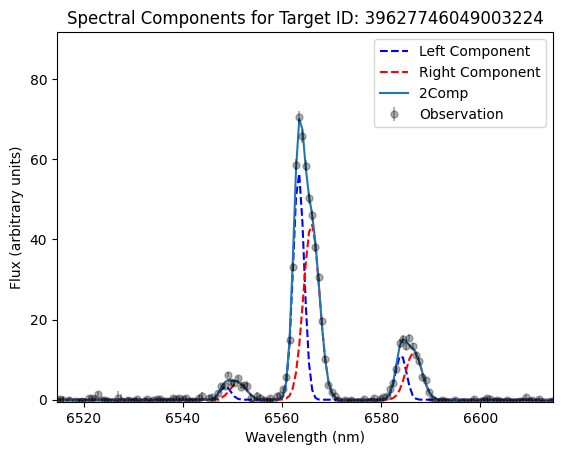

In [14]:
lam, left_component, right_component, flux, ivar = DP_SPECTRA.data_stack[test_idx, 0, :], left_2comp[test_idx], right_2comp[test_idx], DP_SPECTRA.data_stack[test_idx, 1, :], DP_SPECTRA.data_stack[test_idx, 2, :]
plt.plot(lam, left_component, label='Left Component', linestyle='--', color='b')
plt.plot(lam, right_component, label='Right Component', linestyle='--', color='r')
plt.plot(lam, left_component+right_component, label='2Comp')
plt.errorbar(lam, flux, yerr=1/np.sqrt(np.abs(ivar)), label='Observation', fmt='o', color='k', markersize=5, alpha=0.3)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux (arbitrary units)')
plt.title('Spectral Components for Target ID: {}'.format(test_id))
plt.xlim([Halpha_rest[0]-50, Halpha_rest[0]+50])
# plt.xlim([OIII_rest[0]-50, OIII_rest[1]+50])
# plt.xlim([Hbeta_rest[0]-50, Hbeta_rest[0]+50])
plt.ylim(bottom=-0.5, top=np.max(flux[(lam>plt.xlim()[0]) & (lam<plt.xlim()[1])])*1.3)
plt.legend()
plt.show()

In [15]:
sf_dps['delta_dv'] = sf_dps['dv_r'] - sf_dps['dv_l']
print(len(sf_dps[sf_dps['Z']<0.25]))
sf_dps[sf_dps['Z']<0.25].sort_values(by=['delta_dv'], ascending=[False]).head(10)

4801


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/3692883211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sf_dps['delta_dv'] = sf_dps['dv_r'] - sf_dps['dv_l']


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count,BPT_class,delta_dv
7013,39627770300466675,220.048767,-0.752364,0.179621,9.796493,1.199036,179.333450,-197.363495,117.588043,75.155594,...,9,6,7,0,2,5,8,1,double SF,376.696960
6140,39627769788764273,189.681320,-0.696105,0.226918,10.125283,1.769479,158.001724,-213.478546,129.330429,89.097488,...,9,7,8,0,1,5,6,2,SF+uncertain,371.480286
6008,39627769717458009,185.297592,-0.786711,0.209338,10.576923,1.014431,195.612762,-157.502609,33.272694,157.301987,...,9,7,8,0,2,5,6,1,SF+uncertain,353.115356
13398,39627800415574044,215.242844,0.497583,0.151752,10.843871,0.337586,130.150101,-194.382904,159.484070,58.416031,...,9,8,6,0,1,5,7,4,double SF,324.533020
3223,39627757528812438,178.892624,-1.354546,0.082137,10.407084,1.116765,147.303711,-162.515381,121.718719,80.188171,...,9,8,6,0,1,4,7,2,SF+uncertain,309.819092
15775,39627812398694725,209.262955,1.091660,0.103584,10.895995,1.267758,205.585800,-88.141830,62.605698,110.791237,...,9,8,6,0,1,4,7,2,SF+uncertain,293.727631
3720,39627757843385607,197.670868,-1.249344,0.140871,10.909535,0.450157,159.769913,-124.756073,70.835068,115.263924,...,9,8,5,0,1,3,7,2,SF+uncertain,284.526001
12580,39627799870308978,182.524811,0.444552,0.128083,10.819459,1.900950,115.690628,-165.729050,102.041275,89.162476,...,9,8,4,0,1,2,6,4,double SF,281.419678
7060,39627770334024332,222.214172,-0.641080,0.222126,10.565612,0.711782,19.554262,-249.977386,110.737206,47.702835,...,9,7,8,0,1,5,6,2,SF+uncertain,269.531647
10906,39627788348557931,215.843491,-0.077078,0.238490,10.858244,1.789770,199.072357,-70.119049,77.502930,126.211380,...,8,2,5,0,1,7,9,2,SF+COMP,269.191406


In [16]:
agn_dps['delta_dv'] = agn_dps['dv_r'] - agn_dps['dv_l']
print(len(agn_dps[agn_dps['Z']<0.25]))
agn_dps[agn_dps['Z']<0.25].sort_values(by=['delta_dv'], ascending=[False]).head(10)

374


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/2234993131.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agn_dps['delta_dv'] = agn_dps['dv_r'] - agn_dps['dv_l']


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,dp_count,BPT_class,delta_dv
13548,39627800507843254,220.529312,0.442727,0.179778,10.918049,-10.475061,205.131653,-219.842407,147.094284,125.942841,...,6,0,7,2,4,5,8,1,AGN+uncertain,424.974060
13978,39627806014964884,188.788483,0.759762,0.233901,10.619380,1.104108,228.359161,-188.257233,159.991364,125.132973,...,1,0,8,3,2,6,9,5,double AGN,416.616394
338,39627739799486898,202.019196,-1.890129,0.180293,10.764688,-4.672501,196.884781,-198.321320,169.268784,139.532776,...,4,0,6,2,3,8,9,5,double AGN,395.206116
9452,39627782229070929,211.244568,-0.227199,0.239755,10.791212,0.228841,135.680496,-239.877304,121.078331,122.409882,...,3,0,6,2,1,7,9,3,COMP+AGN,375.557800
9190,39627782057099852,200.774597,-0.155745,0.112802,10.687194,0.903828,342.301331,-29.169378,187.646713,211.231705,...,2,0,4,1,3,7,9,1,AGN+uncertain,371.470703
12174,39627794375775082,215.196579,0.361552,0.120998,10.601446,1.092399,20.522406,-324.325806,133.025101,153.617813,...,3,0,6,1,2,7,9,1,AGN+uncertain,344.848206
6809,39627770195608357,213.784317,-0.796851,0.139104,10.604487,1.273112,176.173172,-134.814056,78.573112,116.265343,...,7,2,5,0,1,6,8,3,double AGN,310.987244
1566,39627745977699284,210.411285,-1.645674,0.103915,11.136543,-18.103991,58.931534,-247.405334,137.093491,77.576660,...,9,3,5,0,1,6,8,2,AGN+uncertain,306.336853
17000,39627818400743842,207.016678,1.367162,0.239494,10.189192,1.343240,276.176178,-28.864141,76.854919,113.835754,...,9,3,7,0,1,5,6,2,AGN+uncertain,305.040314
7928,39627776059247645,203.386948,-0.624247,0.145237,10.822559,1.065249,292.294769,-7.562678,233.977341,123.963799,...,4,0,7,1,2,8,9,1,AGN+uncertain,299.857452


In [17]:
sf_dps.to_csv('sf_dps.csv')
agn_dps.to_csv('agn_dps.csv')

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/4282634.py:8: RuntimeWarning: divide by zero encountered in log10
  oiii_hbeta = np.log10(cs_fluxes[:, 1]/cs_fluxes[:, 0])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/4282634.py:9: RuntimeWarning: divide by zero encountered in log10
  nii_halpha = np.log10(cs_fluxes[:, 3]/cs_fluxes[:, 2])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/4282634.py:17: RuntimeWarning: divide by zero encountered in log10
  oiii_hbeta = np.log10(nbcs_fluxes[:, 1]/nbcs_fluxes[:, 0])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/4282634.py:18: RuntimeWarning: divide by zero encountered in log10
  nii_halpha = np.log10(nbcs_fluxes[:, 3]/nbcs_fluxes[:, 2])
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_57195/4282634.py:26: RuntimeWarning: divide by zero encountered in log10
  oiii_hbeta = np.log10(dps_blue_fluxes[:, 1]/dps_blue_fluxes[:, 0])
/var/folders/_b/sl_t4k5539781f29qf723

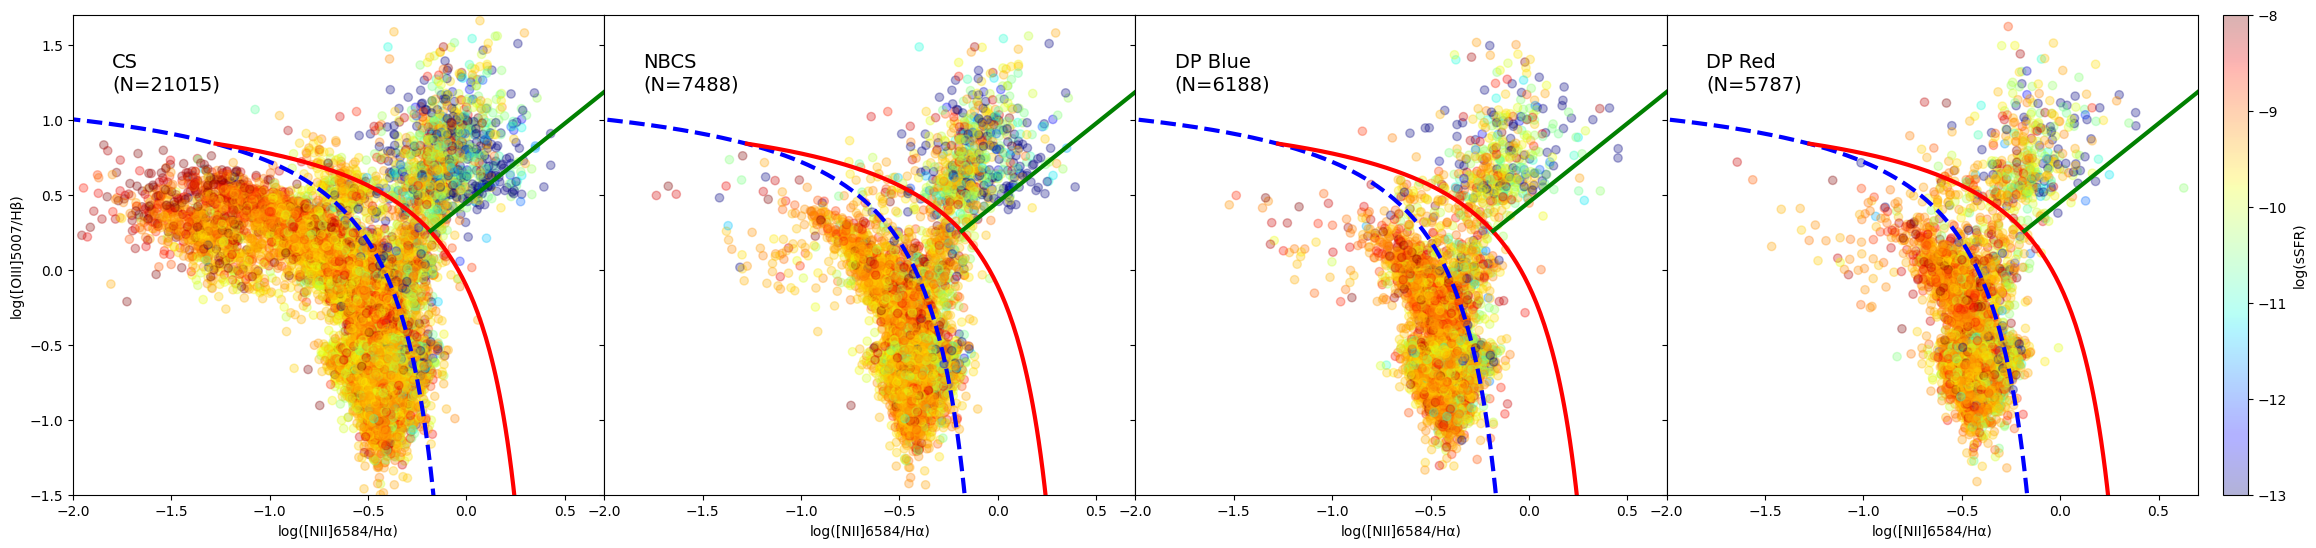

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(25, 6), sharey=True)
plt.subplots_adjust(wspace=0.0, left=0.05, right=0.99, top=0.9, bottom=0.1)


n_cs = len(cs_fluxes)
ssfr_cs = cs_df[cs_df['TARGETID'].isin(cs_ids)]['LOGSFR'] - cs_df[cs_df['TARGETID'].isin(cs_ids)]['LOGM']
cs_fluxes = np.array(cs_fluxes)
oiii_hbeta = np.log10(cs_fluxes[:, 1]/cs_fluxes[:, 0])
nii_halpha = np.log10(cs_fluxes[:, 3]/cs_fluxes[:, 2])
axes[0].scatter(nii_halpha, oiii_hbeta, alpha=0.3, c=ssfr_cs, cmap='jet', vmin=-13, vmax=-8)
axes[0].text(-1.8, 1.2, f'CS\n(N={n_cs})', fontsize=14)


n_nbcs = len(nbcs_fluxes)
nbcs_fluxes = np.array(nbcs_fluxes)
ssfr_nbcs = nbcs_df[nbcs_df['TARGETID'].isin(nbcs_ids)]['LOGSFR'] - nbcs_df[nbcs_df['TARGETID'].isin(nbcs_ids)]['LOGM']
oiii_hbeta = np.log10(nbcs_fluxes[:, 1]/nbcs_fluxes[:, 0])
nii_halpha = np.log10(nbcs_fluxes[:, 3]/nbcs_fluxes[:, 2])
axes[1].scatter(nii_halpha, oiii_hbeta, alpha=0.3, c=ssfr_nbcs, cmap='jet', vmin=-13, vmax=-8)
axes[1].text(-1.8, 1.2, f'NBCS\n(N={n_nbcs})', fontsize=14)


n_dps_left = len(dps_blue_fluxes)
dps_blue_fluxes = np.array(dps_blue_fluxes)
ssfr_blue = dps_df[dps_df['TARGETID'].isin(dps_blue_ids)]['LOGSFR'] - dps_df[dps_df['TARGETID'].isin(dps_blue_ids)]['LOGM']
oiii_hbeta = np.log10(dps_blue_fluxes[:, 1]/dps_blue_fluxes[:, 0])
nii_halpha = np.log10(dps_blue_fluxes[:, 3]/dps_blue_fluxes[:, 2])
axes[2].scatter(nii_halpha, oiii_hbeta, alpha=0.3, c=ssfr_blue, cmap='jet', vmin=-13, vmax=-8)
axes[2].text(-1.8, 1.2, f'DP Blue\n(N={n_dps_left})', fontsize=14)
        
n_dps_right = len(dps_red_fluxes)
dps_red_fluxes = np.array(dps_red_fluxes)
ssfr_red = dps_df[dps_df['TARGETID'].isin(dps_red_ids)]['LOGSFR'] - dps_df[dps_df['TARGETID'].isin(dps_red_ids)]['LOGM']
oiii_hbeta = np.log10(dps_red_fluxes[:, 1]/dps_red_fluxes[:, 0])
nii_halpha = np.log10(dps_red_fluxes[:, 3]/dps_red_fluxes[:, 2])
sc = axes[3].scatter(nii_halpha, oiii_hbeta, alpha=0.3, c=ssfr_red, cmap='jet', vmin=-13, vmax=-8)
axes[3].text(-1.8, 1.2, f'DP Red\n(N={n_dps_right})', fontsize=14)

for i in range(4):
    ax = axes[i]
    ax.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], color='blue', linewidth=3, linestyle='--')
    ax.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], color='red', linewidth=3)
    ax.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], color='green', linewidth=3)
    ax.set_xlabel('log([NII]6584/Hα)')
    if i == 0:
        ax.set_ylabel('log([OIII]5007/Hβ)')
    ax.set_xlim(-2, .7)
    ax.set_ylim(-1.5, 1.7)

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.10, 0.01, 0.8])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('log(sSFR)')
# plt.tight_layout()
plt.savefig('./figures/Jan22/bpt_diagram.png')
plt.show()